# Chapter 5. 모델 평가와 성능 향상
- 분류에서 score 메서드는 정확히 분류된 샘플의 비율을 계산하는 역할을 수행
- 모델이 훈련 세트에 잘 맞는 것보다, **학습 과정에 없던 데이터에 대해 예측을 얼마나 잘 하느냐가 중요**
- 이번 Chapter에서 다루는 내용
> - **안정적인 일반화 성능 측정 방법인 교차 검증**을 소개
> - score 메서드가 제공하는 정확도와 R2 값 이외에 **분류와 회귀 성능을 측정하는 다른 방법**
> - 지도 학습 모델의 **매개변수를 조정하는 데 유용한 그리드 서치**에 관해서도 다룸

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import IPython
import sklearn
import mglearn

print('Python 버전:', sys.version)
print('numpy 버전:', np.__version__)
print('pandas 버전:', pd.__version__)
print('matplotlib 버전:', matplotlib.__version__)

print('SciFy 버전:', sp.__version__)
print('IPython 버전:', IPython.__version__)
print('scikit-learn 버전:', sklearn.__version__)

from sklearn.model_selection import train_test_split
#plt.rc('font', family="Apple SD Gothic Neo")

Python 버전: 3.11.4 (main, Jul  5 2023, 14:15:25) [GCC 11.2.0]
numpy 버전: 1.24.3
pandas 버전: 1.5.3
matplotlib 버전: 3.7.1
SciFy 버전: 1.10.1
IPython 버전: 8.12.0
scikit-learn 버전: 1.2.2


## 5.1 교차 검증
- 교차 검증은 일반화 성능을 재기 위해 훈련 세트와 테스트 세트로 한 번 나누는 것보다 더 안정적이고 뛰어난 통계적 평가 방법임
- **교차 검증에서는 데이터를 여러 번 반복해서 나누고 여러 모델을 학습**
- 기본 KFold, StratifiedKFold, GroupKFold를 가장 널리 사용

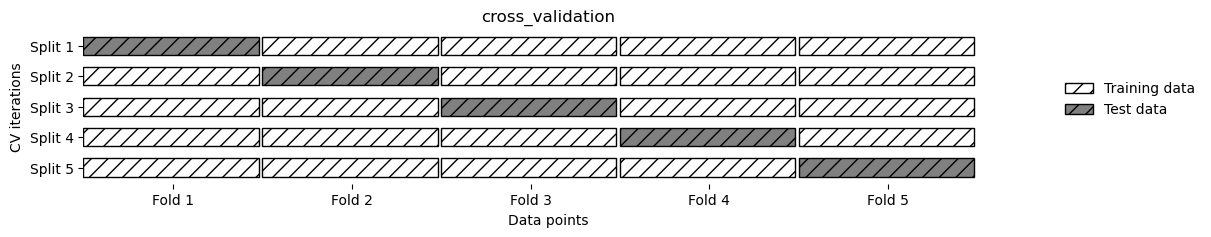

In [7]:
# k-겹 교차 검증
mglearn.plots.plot_cross_validation()

- **보통 데이터의 첫 번째 1/5 조각이 첫 번째 폴드이고 두 번째 1/5 조각이 두 번째 폴드가 되는 식**

### 5.1.1 scikit-learn의 교차 검증
- scikit-learn에서 교차 검증은 ***model_selection* 모듈의 *cross_val_score* 함수로 구현**
- ***cross_val_score* 함수의 매개변수는 평가하려는 모델과 훈련 데이터, 타깃 레이블**

In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
logreg = LogisticRegression(max_iter=1000)

scores = cross_val_score(logreg, iris.data, iris.target, cv=10)
scores

array([1.        , 0.93333333, 1.        , 1.        , 0.93333333,
       0.93333333, 0.93333333, 1.        , 1.        , 1.        ])

- 폴드의 수는 *cv* 매개변수를 사용해서 변경할 수 있음, 기본값은 5임

> - 교차 검증에 ***cross_validate* 함수를 사용할 수도 있음**
> - 이 함수는 *cross_val_score* 함수와 인터페이스가 비슷하지만 분할마다 훈련과 테스트에 걸린 시간을 담은 딕셔너리를 반환
> - 테스트 점수는 물론 설정에 따라 훈련 점수도 얻을 수 있음
> - ***cross_val_score*는 *cross_validate* 함수에서 반환된 결과 중 'test_score' 키만 반환하는 개념임**

In [15]:
from sklearn.model_selection import cross_validate
res = cross_validate(logreg, iris.data, iris.target, return_train_score = True, cv=10)
res

{'fit_time': array([0.02273631, 0.017313  , 0.02015185, 0.01898026, 0.02057266,
        0.02011919, 0.01900291, 0.01476264, 0.01887727, 0.02362347]),
 'score_time': array([0.00066614, 0.00061512, 0.00089669, 0.00057173, 0.00066757,
        0.00054812, 0.00053716, 0.00051022, 0.0007875 , 0.00056362]),
 'test_score': array([1.        , 0.93333333, 1.        , 1.        , 0.93333333,
        0.93333333, 0.93333333, 1.        , 1.        , 1.        ]),
 'train_score': array([0.97037037, 0.97777778, 0.97037037, 0.97037037, 0.97777778,
        0.97777778, 0.98518519, 0.97037037, 0.97037037, 0.97777778])}

In [17]:
# pandas를 사용하여 결괏값을 출력하고 평균을 계산
res_df = pd.DataFrame(res)
res_df

,fit_time,score_time,test_score,train_score
0,0.022736,0.000666,1.000000,0.970370
1,0.017313,0.000615,0.933333,0.977778
2,0.020152,0.000897,1.000000,0.970370
3,0.018980,0.000572,1.000000,0.970370
4,0.020573,0.000668,0.933333,0.977778
5,0.020119,0.000548,0.933333,0.977778
6,0.019003,0.000537,0.933333,0.985185
7,0.014763,0.000510,1.000000,0.970370
8,0.018877,0.000787,1.000000,0.970370
9,0.023623,0.000564,1.000000,0.977778


In [19]:
print('평균 시간과 점수:\n', res_df.mean())

평균 시간과 점수:
 fit_time       0.019614
score_time     0.000636
test_score     0.973333
train_score    0.974815
dtype: float64


### 5.1.2 교차 검증의 장점
- 교차 검증의 점수를 (그리고 평균값을) 높이기 위해서는 데이터 셋에 있는 모든 샘플에 대해 모델이 잘 일반화 되어야 함
- 데이터를 여러개로 나누면 모델이 훈련 데이터에 얼마나 민감한지 알 수 있음 -> **새로운 데이터를 적용했을 때 최악의 경우와 최선의 경우를 짐작 할 수 있음**
- **교차 검증의 주요 단점은 연산 비용이 늘어난다는 점**

- **주의점**
> - 교차 검증이 새로운 데이터에 적용할 모델을 만드는 방법이 아니라는 점을 기억, **교차 검증 함수는 모델을 반환하지 않음**
> - *cross_val_score* 함수를 호출하면 내부적으로 여러 모델이 만들어지지만 교차 검증의 목적은 단지 주어진 데이터셋에 학습된 알고리즘이 얼마나 잘 일반화될지 평가하는 것
> - 교차 검증으로 모델을 만들어낼 수는 없지만 ***sklearn.model_selection* 모듈의 *cross_val_predict* 함수를 사용하여 교차 검증으로 만든 예측값을 구할 수 있음**
> - ***cross_val_predict(model, X, y, cv=10)와* 같이 호출하면 각 폴드가 테스트 세트일 때 예측된 값을 반환**

### 5.1.3 계층별 k-겹 교차 검증과 그외 전략들
- 경우에 따라 **데이터 셋을 나열 순서대로 k개의 폴드로 나누는 것**이 항상 좋지 않음 (데이터가 편중되어 배치 되었을 경우)
- scikit-learn은 **분류일 경우** 이 방법 대신 **계층별 k-겹 교차 검증(stratified k-fold cross-validation)을 사용**
- **계층별 교차 검증에서는 아래 그림처럼 폴드 안의 클래스 비율이 전체 데이터셋의 클래스 비율과 같도록 데이터를 나눔**
- 분류기의 일반화 성능을 측정할 때 k-겹 교차 검증보다 더 안정적인 계층별 k-겹 교차 검증을 사용하는 것이 좋음

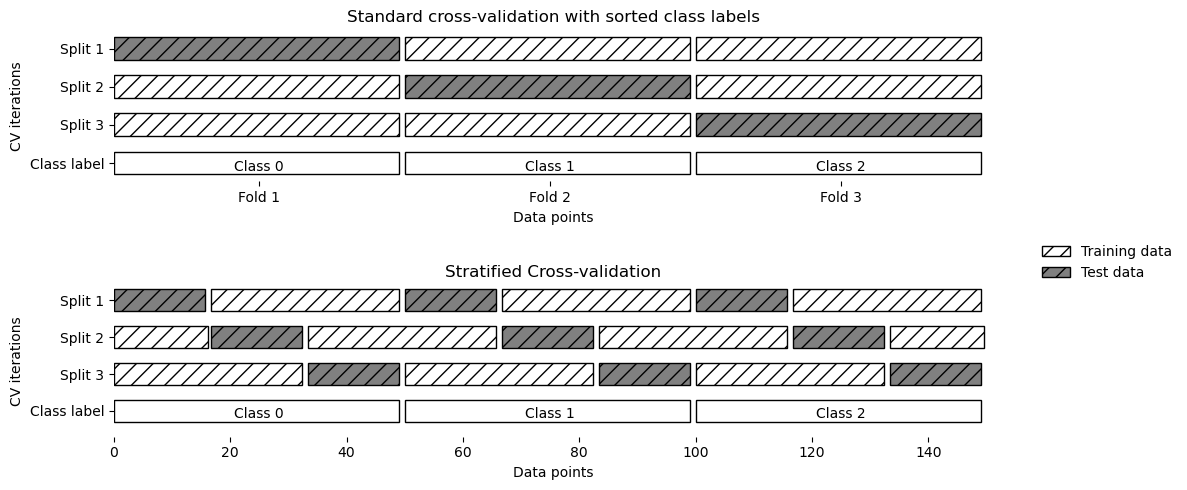

In [23]:
mglearn.plots.plot_stratified_cross_validation()

- *cross_val_score* 함수에서는 폴드를 나눌때 기본적으로 **분류에는 StratifiedKFold를 사용(기본값)하여 훈련 세트와 테스트 세트를 나누고, 회귀에는 단순한 KFold를 적용함**
- **KFold에서 shuffle 매개변수를 기본값 False 대신 True로 지정하면 폴드를 나누기 전에 무작위로 섞을 수 있음**
- 하지만, *cross_val_score* 함수를 사용할 때 KFold 매개변수를 제어할 방법이 없으므로 **그 전에 KFold 객체를 만들어 *cross_val_score* 함수의 cv 매개변수로 전달해야함**

#### <U>*교차 검증 상세 옵션*</U>
- scikit-learn에서는 **cv 매개변수에 교차 검증 분할기(cross-validation splitter, KFold)를 전달함으로써 데이터를 분할할 때 더 세밀하게 제어 가능함**
- 데이터를 섞을 때 *random_state*를 고정해서 교차 검증 실행시 똑같은 결과를 재현할 수 있음

In [27]:
from sklearn.model_selection import KFold
kfold = KFold(n_splits=3)
print(iris.target)
cross_val_score(logreg, iris.data, iris.target, cv=kfold)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


array([0., 0., 0.])

- 기본 k-fold 적용시 순차적으로 3등분하면 각 폴드는 하나의 타겟 레이블만 대응하므로 아무것도 학습할 수 없음

> - KFold 객체 선언시 shuffle 매개변수를 통해 데이터를 섞어줌으로써 해당 문제 해결 가능 

In [31]:
kfold = KFold(n_splits=3, shuffle=True, random_state=0)
cross_val_score(logreg, iris.data, iris.target, cv= kfold)

array([0.98, 0.96, 0.96])

#### <U>*LOOCV*</U>
- **LOOCV(Leave-one-out-validation) 교차 검증은 폴드 하나에 샘플 하나만 들어 있는 k-겹 교차 검증으로 생각**
- 작은 데이터셋에서는 이따금 더 좋은 결과를 만들기도 함

In [34]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
scores = cross_val_score(logreg, iris.data, iris.target, cv=loo)

print('교차검증 분할 횟수: ', len(scores))
scores.mean()

교차검증 분할 횟수:  150


0.9666666666666667

#### <U>*임의 분할 교차 검증*</U>
- 매우 유연한 또 하나의 교차 검증 전략은 임의 분할 교차 검증(shuffle-split cross-validation)
- **train_size 만큼의 포인트로 훈련 세트를 만들고, test_size 만큼의 (훈련 세트와 중첩X) 포인트로 테스트 세트를 만들도록 분할(n_split 횟수만큼 반복)**
- 위 매개변수에 정수를 입력하면 데이터 포인트의 절대 개수 의미, 실수를 입력하면 전체 데이터에서의 비율

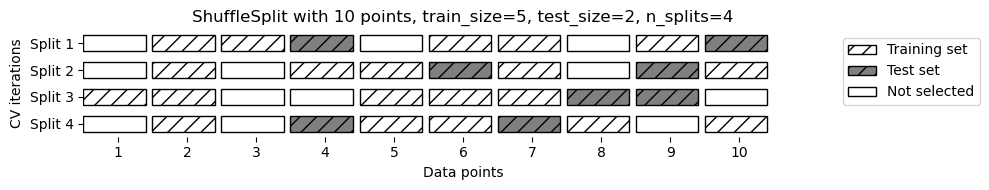

In [37]:
mglearn.plots.plot_shuffle_split()

- ShuffleSplit은 데이터에서 무작위로 추출하여 훈련 세트와 테스트 세트를 만드므로 필요시 random_state 매개변수를 지정
- **KFold와는 다르게, 하나의 데이터 포인트가 여러 테스트 세트에 포함될 수 있음**

In [76]:
# 데이터셋의 50%를 훈련 세트로, 50%를 테스트 세트로 10번 반복 분할
from sklearn.model_selection import ShuffleSplit
shuffle_split = ShuffleSplit(test_size=0.5, train_size=0.5, n_splits=10)
scores = cross_val_score(logreg, iris.data, iris.target, cv=shuffle_split)
scores

array([0.96      , 0.97333333, 0.92      , 0.96      , 0.96      ,
       0.96      , 0.93333333, 0.96      , 0.89333333, 0.96      ])

- 반복 횟수를 훈련 세트나 테스트 세트의 크기와 독립적으로 조절해야할 때 유용
- **훈련과 테스트 데이터의 합을 전체와 다르게 함으로써 부분 샘플링 효과 -> 대규모 데이터셋으로 작업할 때 도움**
- ShuffleSplit의 계층별 버전으로 분류 작업에 더 적합한 StratifiedShuffleSplit도 있음

#### <U>*그룹별 교차 검증*</U>
- **훈련 세트와 테스트 세트를 만들 때 분리되지 않아야 할 그룹을 지정하여 교차 검증을 수행할 수 있음**
- 계층별 k-겹 교차 검증인 stratified_cross_validation의 **클래스 레이블(타깃)과 혼동해서는 안됨**
- (예시) 같은 환자로부터 얻은 여러 샘플을 가지고 새로운 환자에게 일반화하는 것이 목적일때 **같은 환자의 샘플들이 테스트 셋에 포함되지 않도록 해야함**

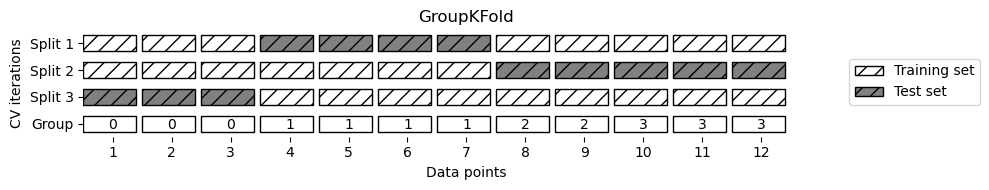

In [42]:
mglearn.plots.plot_group_kfold()

- 샘플 데이터가 위 예시처럼 꼭 그룹으로 정렬될 필요는 없음, 분할은 그룹 레이블을 기반으로 계산
- 각 분할에서 한 그룹 전체가 훈련 세트 아니면 테스트 세트에 할당

In [72]:
# 위 사례 실제 코드 예시
from sklearn.model_selection import GroupKFold
from sklearn.datasets import make_blobs

# 인위적 데이터셋 생성
X, y = make_blobs(n_samples=12, random_state=0)
# 처음 3개의 샘플은 같은 그룹에 속하고 다음은 4개의 샘플이 같음
groups = [0,0,0,1,1,1,1,2,2,3,3,3]
scores = cross_val_score(logreg, X, y, groups=groups, cv=GroupKFold(n_splits=3))
scores

array([0.75      , 0.6       , 0.66666667])

- cross_val_score 함수로 넘겨진 groups 매개변수는 함수 내부에서 cv.splits() 메서드를 호출할 때 groups를 매개변수로 전달

### 5.1.4 반복 교차 검증
- 데이터셋의 크기가 크지 않을 경우 안정된 검증 점수를 얻기 위해 **교차 검증을 반복하여** 여러 번 수행
- 회귀에는 RepeatedKFold, 분류에는 RepeatedStratifiedKFold 사용
- 분할 폴드 수는 n_splits 매개변수로 설정(기본값 5), **반복 횟수는 n_repeats 매개변수로 설정(기본값 10), 반복할 때마다 데이터를 다시 섞음**

In [3]:
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
logreg = LogisticRegression(max_iter=1000)

In [5]:
from sklearn.model_selection import RepeatedStratifiedKFold

rskfold = RepeatedStratifiedKFold(random_state=42)
scores = cross_val_score(logreg, iris.data, iris.target, cv=rskfold)

print('교차 검증 점수:\n', scores)
print('교차 검증 평균점수: {:.3f}'.format(scores.mean())) 

교차 검증 점수:
 [1.         0.96666667 0.93333333 1.         0.93333333 0.96666667
 0.96666667 0.93333333 1.         0.96666667 0.93333333 1.
 1.         0.96666667 0.96666667 0.9        1.         1.
 0.93333333 0.96666667 0.93333333 0.96666667 0.96666667 1.
 0.96666667 1.         0.96666667 0.96666667 0.9        1.
 0.96666667 0.96666667 0.96666667 0.96666667 0.93333333 0.96666667
 0.96666667 1.         1.         0.9        0.96666667 1.
 0.9        0.96666667 0.96666667 0.9        0.96666667 0.96666667
 1.         0.96666667]
교차 검증 평균점수: 0.965


## 5.2 그리드 서치
- 관심 있는 매개변수들을 대상으로 가능한 모든 조합을 시도해 보는 것

### 5.2.1 간단한 그리드 서치
- for 문을 사용해 구현

In [9]:
# 간단한 그리드 서치 구현
from sklearn.svm import SVC
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=0)
X_train.shape, X_test.shape

((112, 4), (38, 4))

In [11]:
best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        #매개변수의 각 조합에 대해 SVC를 훈련
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        #테스트 세트로 SVC를 평가
        score = svm.score(X_test, y_test)
        #점수가 더 높으면 매개변수와 함께 기록
        if score > best_score:
            best_score = score
            best_parameters = {'C':C, 'gamma':gamma}

print('최고점수:{:.2f}'.format(best_score))
print('최적 매개변수:', best_parameters)


최고점수:0.97
최적 매개변수: {'C': 100, 'gamma': 0.001}


### 5.2.2 매개변수 과대적합과 검증 세트
- **매개변수를 조정하기 위해 테스트 세트를 이미 사용**했기 때문에 모델의 일반화 성능을 단정하기에는 위험요소가 있음
- 일반화 성능에 대한 평가를 위해서는 **모델을 만들때 사용하지 않은 독립된 데이터 셋이 필요**
- **3개의 세트**로 나눈 것을 추천 : 1. 훈련 세트로는 모델을 만들고, **2. 검증(또는 개발) 세트로는 모델의 매개변수를 선택, 3. 테스트 세트로는 선택된 매개변수의 일반화 성능을 평가**

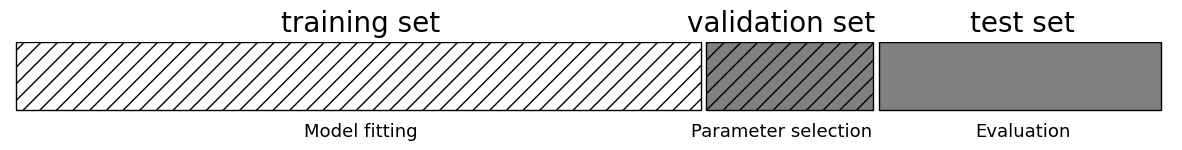

In [14]:
mglearn.plots.plot_threefold_split()

-> **검증 세트를 사용해 최적의 매개변수를 선택한 후, 그 매개변수에서 훈련 세트와 검증 세트 데이터를 모두 이용해 모델 생성**(최대한 많은 데이터 이용)

In [17]:
from sklearn.svm import SVC
#데이터를 훈련+검증세트 그리고 테스트 세트로 1차 분할
X_trainval, X_test, y_trainval, y_test = train_test_split(iris.data, iris.target, random_state=0)
#훈련+검증 세트를 훈련 세트와 검증 세트로 2차 분할
X_train, X_valid, y_train, y_valid = train_test_split(X_trainval, y_trainval, random_state=1)
X_train.shape, X_valid.shape, X_test.shape

((84, 4), (28, 4), (38, 4))

In [19]:
best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        #검증 세트로 SVC를 평가
        score = svm.score(X_valid, y_valid)
        #점수가 더 높으면 매개변수와 함께 기록
        if score>best_score:
            best_score = score
            best_parameters = {'C':C, 'gamma':gamma}

# 훈련 세트와 검증 세트를 합쳐 모델을 다시 만든 후 테스트 세트를 사용해 일반화 성능 평가
svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)
test_score = svm.score(X_test, y_test)

print('검증 세트에서 최고 점수: {:.2f}'.format(best_score))
print('최적 매개변수: ', best_parameters)
print('최적 매개변수에서 테스트 세트 점수: {:.2f}'.format(test_score))

검증 세트에서 최고 점수: 0.96
최적 매개변수:  {'C': 10, 'gamma': 0.001}
최적 매개변수에서 테스트 세트 점수: 0.92


### 5.2.3 교차 검증을 사용한 그리드 서치
- 일반화 성능을 더 잘 평가하려면 **훈련 세트와 검증 세트를 한 번만 나누지 않고, 교차 검증을 사용해서 각 매개변수 조합의 성능을 평가**
- **교차 검증은 어떤 데이터셋에 대해 주어진 알고리즘을 평가하는 방법, 하지만 그리드 서치와 같은 매개변수 탐색 방법과 합쳐서 많이 사용**
- 많은 사람이 교차 검증이란 용어를 ***교차 검증을 적용한 그리드 서치라는 의미로 주로 사용***

In [22]:
best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        #매개변수의 각 조합에 대해 SVC를 훈련
        svm = SVC(gamma=gamma, C=C)
        #교차 검증을 적용
        scores = cross_val_score(svm, X_trainval, y_trainval, cv=5)
        #교차 검증 정확도의 평균을 계산
        score = np.mean(scores)
        #점수가 더 높으면 매개변수와 함께 기록
        if score>best_score:
            best_score = score
            best_parameters = {'C':C, 'gamma':gamma}

# 훈련 세트와 검증 세트를 합쳐 모델을 다시 생성
svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)

SVC(C=10, gamma=0.1)

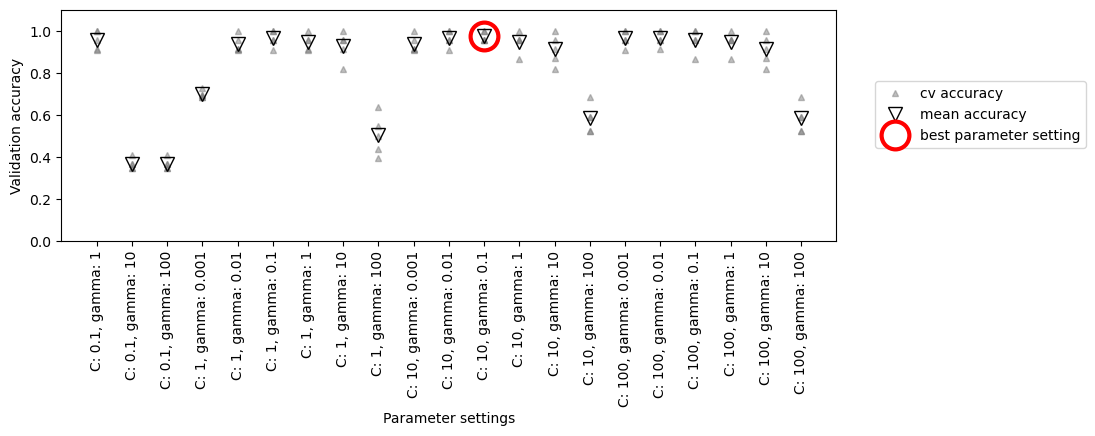

In [24]:
mglearn.plots.plot_cross_val_selection()

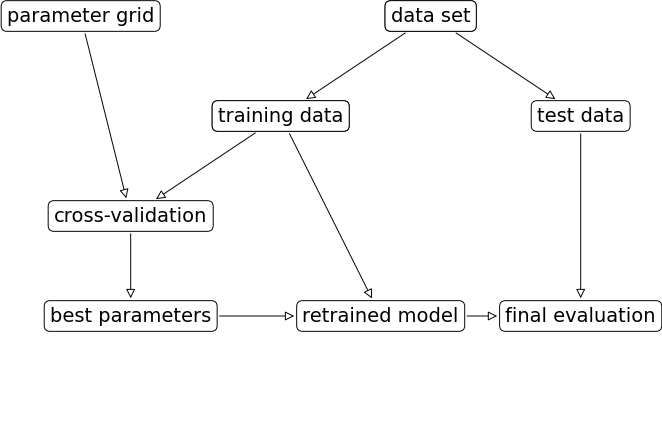

In [25]:
mglearn.plots.plot_grid_search_overview()

- 교차 검증을 사용한 그리드 서치를 매개변수 조정 방법으로 널리 사용하기 때문에 **사이킷런에서 추정기 형태로 구현된 GridSearchCV를 제공(GridSearch+CV)**
- **딕셔너리 형태로 검색 대상 매개변수를 지정하여 넘겨줌**

In [27]:
param_grid = {'C':[0.001, 0.01, 0.1, 1, 10, 100], 'gamma':[0.001, 0.01, 0.1, 1, 10, 100]}
print('매개변수 그리드:\n', param_grid)

매개변수 그리드:
 {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}


> - **모델(SVC), 검색 대상 매개변수 그리드(param_grid), 원하는 교차 검증(5겹-계층별)으로 GridSearchCV의 객체 생성**
> - cv_results_ 속성에 훈련 폴드의 점수를 포함시키려면 True로 설정(기본값 False)

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=0)

grid_search = GridSearchCV(SVC(), param_grid, cv=5, return_train_score=True)

> - fit 메서드를 호출하면 param_grid에 설정된 매개변수 조합에 대한 교차 검증을 수행
> - **fit 메서드는 최적의 매개변수를 찾는 일뿐만 아니라, 교차 검증 성능이 가장 좋은 매개변수로 전체 훈련셋에 대해 새로운 모델을 자동으로 생성**
> - 본 절 첫번째 코드의 결과와 대등! 

In [35]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'gamma': [0.001, 0.01, 0.1, 1, 10, 100]},
             return_train_score=True)

- 다른 추정기를 사용해 만든 추정기를 scikit-learn에서는 메타 추정기라고 하며, GridSearchCV는 가장 널리 사용하는 메타 추정기임
- scikit-learn에서 MetaEstimatorMixin 클래스를 상속한 모델을 메타 추정기라고 하며, 랜덤 포레스트, 그레디언트부스팅, RFE등이 메타 추정기 중 하나임

> - GridSearchCV는 전체 데이터로 학습한 모델에 접근할 수 있도록 predict와 score 메서드를 제공
> - **찾은 최적 매개변수로 일반화 성능을 평가하려면 테스트 세트를 매개변수로 넘겨 score 메서드를 호출하면 됨**
> - 모델에 따라서는 predict_proba, decision_function 같은 메서드도 사용 가능

In [39]:
print('테스트 세트 점수: {:.2f}'.format(grid_search.score(X_test, y_test)))

테스트 세트 점수: 0.97


> - **선택한 매개변수는 best_params_ 속성에 기록, 최상의 교차 검증 정확도는 (이 매개변수 설정으로 각 분할에서 얻은 정확도의 평균) best_score_에 저장**

In [42]:
print('최적 매개변수:', grid_search.best_params_)
print('최고 교차 검증 점수: {:.2f}'.format(grid_search.best_score_))

최적 매개변수: {'C': 10, 'gamma': 0.1}
최고 교차 검증 점수: 0.97


- **주의: 테스트 세트로 score 메서드에서 계산하는 모델의 일반화 성능과 best_score_를 혼동하지 말 것**
- score 메서드는 (또는 predict 결과) 전체 훈련 세트에서 학습한 모델("retrained model")에 대한 것
- best_score_ 속성에는 훈련 세트에서 수행한 교차 검증의 평균 정확도 -> 위 케이스에서는 5-겹 교차 검증이 적용되었으므로 훈련 세트 중 4개의 폴드를 사용하여 학습한 모델의 평균 정확도가 기록, 본절 첫 번째 코드 참조할 것

> - **최적의 매개변수에서 전체 훈련 세트를 사용하여 학습한 모델은 *best_estimator_* 속성에서 얻을 수 있음**
> - grid_search 객체가 predict와 score 메서드를 가지고 있으므로 예측이나 모델 평가를 위해 best_estimator_ 속성을 사용할 필요는 없음

In [46]:
print('최고 성능 모델:\n', grid_search.best_estimator_)

최고 성능 모델:
 SVC(C=10, gamma=0.1)


#### <U>*교차 검증 결과 분석*</U>
- 그리드 서치는 연산 비용이 매우 크므로 비교적 간격을 넓게 하여 적은 수의 그리드로 시작 -> 교차 검증된 결과를 분석하여 그리드 서치 검색을 확장

In [49]:
pd.set_option('display.max_columns', None)
# DataFrame으로 변환
results = pd.DataFrame(grid_search.cv_results_)
np.transpose(results.head())

,0,1,2,3,4
mean_fit_time,0.001338,0.001399,0.001149,0.001259,0.001099
std_fit_time,0.000173,0.000275,0.000058,0.000264,0.000018
mean_score_time,0.00066,0.000723,0.000581,0.000672,0.000623
std_score_time,0.000058,0.00017,0.000025,0.00014,0.000141
param_C,0.001,0.001,0.001,0.001,0.001
param_gamma,0.001,0.01,0.1,1,10
params,"{'C': 0.001, 'gamma': 0.001}","{'C': 0.001, 'gamma': 0.01}","{'C': 0.001, 'gamma': 0.1}","{'C': 0.001, 'gamma': 1}","{'C': 0.001, 'gamma': 10}"
split0_test_score,0.347826,0.347826,0.347826,0.347826,0.347826
split1_test_score,0.347826,0.347826,0.347826,0.347826,0.347826
split2_test_score,0.363636,0.363636,0.363636,0.363636,0.363636


In [51]:
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.001338,0.000173,0.000660,0.000058,0.001,0.001,"{'C': 0.001, 'gamma': 0.001}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22,0.370787,0.370787,0.366667,0.366667,0.355556,0.366092,0.005581
1,0.001399,0.000275,0.000723,0.000170,0.001,0.01,"{'C': 0.001, 'gamma': 0.01}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22,0.370787,0.370787,0.366667,0.366667,0.355556,0.366092,0.005581
2,0.001149,0.000058,0.000581,0.000025,0.001,0.1,"{'C': 0.001, 'gamma': 0.1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22,0.370787,0.370787,0.366667,0.366667,0.355556,0.366092,0.005581
3,0.001259,0.000264,0.000672,0.000140,0.001,1,"{'C': 0.001, 'gamma': 1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22,0.370787,0.370787,0.366667,0.366667,0.355556,0.366092,0.005581
4,0.001099,0.000018,0.000623,0.000141,0.001,10,"{'C': 0.001, 'gamma': 10}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22,0.370787,0.370787,0.366667,0.366667,0.355556,0.366092,0.005581


In [53]:
# 교차 검증의 평균을 뽑아서 param 셋팅(C, gamma) 변수 숫자에 맞춰 재배열
scores = np.array(results.mean_test_score).reshape(6,6)

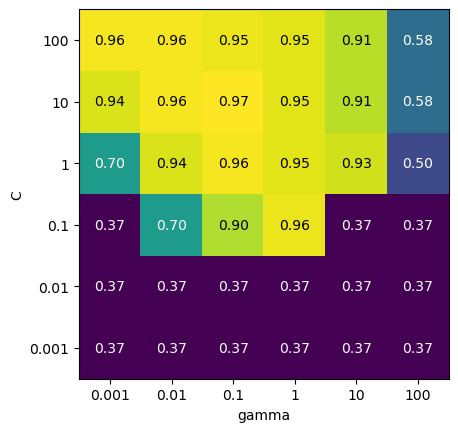

In [55]:
# 교차 검증 평균 점수 히트맵 그래프
mglearn.tools.heatmap(scores, xlabel='gamma', xticklabels=param_grid['gamma'],
                      ylabel='C', yticklabels=param_grid['C'], cmap='viridis')
#plt.ticklabel_format(axis='x', style='plain')

> - 그리드 서치 진행시 파라미터 탐색 범위가 적절하게 셋팅 되지 못한 예시

In [58]:
param_grid_linear = {'C':np.linspace(1,2,6), 'gamma':np.linspace(1,2,6)}
param_grid_one_log = {'C': np.linspace(1,2,6), 'gamma': np.round(np.logspace(-3,2,6),3)}
param_grid_range = {'C': np.round(np.logspace(-3,2,6),3), 'gamma': np.round(np.logspace(-7,-2,6),3)}

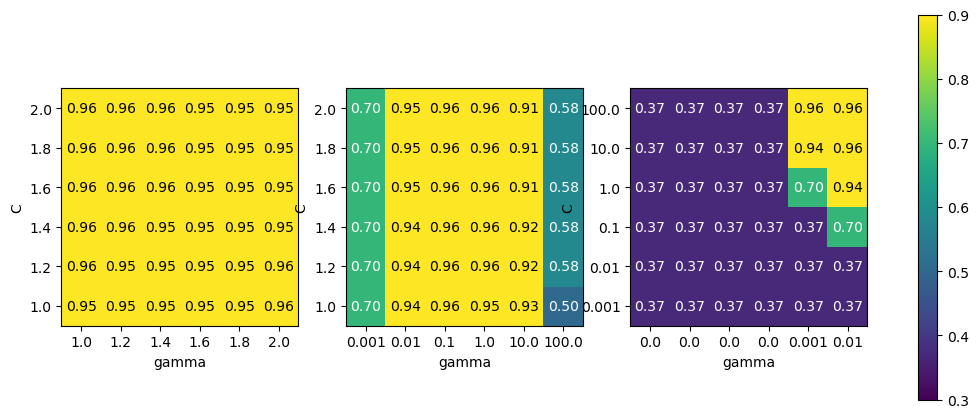

In [60]:
fig, axes = plt.subplots(1,3, figsize=(13,5))

for param_grid, ax in zip([param_grid_linear, param_grid_one_log, param_grid_range], axes):
    grid_search = GridSearchCV(SVC(), param_grid, cv=5)
    grid_search.fit(X_train, y_train)
    scores = grid_search.cv_results_['mean_test_score'].reshape(6,6)
    
    scores_image = mglearn.tools.heatmap(scores, xlabel='gamma', xticklabels=param_grid['gamma'],
                      ylabel='C', yticklabels=param_grid['C'], cmap='viridis', ax=ax, vmin=0.3, vmax=0.9)

plt.colorbar(scores_image, ax=axes.tolist())

- 교차 검증 점수를 토대로 매개변수 그리드를 튜닝하는 것은 아주 안전한 방법이며, 매개변수의 중요도를 확인하는 데도 좋음
- **최종 테스트 세트를 대상으로 여러 매개변수 범위를 테스트해서는 안됨**

#### <U>*비대칭 매개변수 그리트 탐색*</U>
- 조건부 매개변수 조합을 적용하려면 GridSearchCV에 전달한 param_grid를 **딕셔너리의 리스트**로 작성
- **리스트에 있는 각 딕셔너리는 독립적인 그리드로 적용**
> - SVC의 kernel 종류에 따른 매개변수 그리드 예시

In [63]:
param_grid = [
    {'kernel':['rbf'], 'C':[0.001,0.01,0.1,1,10,100], 'gamma':[0.001,0.01,0.1,10,100]},
    {'kernel':['linear'], 'C':[0.001,0.01,0.1,1,10,100]}
             ]
print('그리드 목록:\n', param_grid)

그리드 목록:
 [{'kernel': ['rbf'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 10, 100]}, {'kernel': ['linear'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}]


In [66]:
# 매개변수 그리드를 적용
grid_search = GridSearchCV(SVC(), param_grid, cv=5, return_train_score=True)
grid_search.fit(X_train, y_train)

print('최적 파라미터:', grid_search.best_params_)
print('최고 교차 검증 점수: {:.2f}'.format(grid_search.best_score_))

최적 파라미터: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
최고 교차 검증 점수: 0.97


In [67]:
results = pd.DataFrame(grid_search.cv_results_)
results.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
mean_fit_time,0.001491,0.001168,0.001155,0.00109,0.001256,0.001051,0.001094,0.001111,0.001413,0.002004,0.001708,0.001735,0.001527,0.001437,0.001369,0.001177,0.000881,0.000837,0.001407,0.00157,0.000859,0.000739,0.000727,0.001246,0.001388,0.000754,0.000824,0.000812,0.001346,0.001401,0.001106,0.000973,0.000839,0.000797,0.000978,0.000788
std_fit_time,0.000417,0.000056,0.000096,0.00003,0.000131,0.000017,0.000048,0.000052,0.000295,0.000048,0.00009,0.000042,0.000052,0.00039,0.000191,0.000218,0.000024,0.00019,0.000281,0.000364,0.000019,0.000013,0.000023,0.000036,0.000053,0.00005,0.00017,0.000113,0.00004,0.000057,0.000052,0.000036,0.000056,0.000035,0.000212,0.000025
mean_score_time,0.000717,0.000605,0.0006,0.000581,0.000654,0.000571,0.000573,0.000595,0.000762,0.000967,0.000936,0.000936,0.000937,0.000657,0.000686,0.000623,0.000535,0.000546,0.000567,0.000694,0.000535,0.000488,0.000465,0.000581,0.000591,0.000498,0.000563,0.000511,0.000564,0.000648,0.000512,0.000531,0.00054,0.000521,0.000641,0.000502
std_score_time,0.0001,0.000022,0.000035,0.000026,0.000056,0.00002,0.000006,0.000045,0.000163,0.000019,0.000028,0.000005,0.000017,0.000145,0.000172,0.000139,0.000018,0.000092,0.000012,0.000159,0.000014,0.000005,0.000002,0.000073,0.000011,0.000015,0.000145,0.000051,0.000015,0.000027,0.000017,0.000018,0.000024,0.000004,0.000092,0.000007
param_C,0.001,0.001,0.001,0.001,0.001,0.01,0.01,0.01,0.01,0.01,0.1,0.1,0.1,0.1,0.1,1,1,1,1,1,10,10,10,10,10,100,100,100,100,100,0.001,0.01,0.1,1,10,100
param_gamma,0.001,0.01,0.1,10,100,0.001,0.01,0.1,10,100,0.001,0.01,0.1,10,100,0.001,0.01,0.1,10,100,0.001,0.01,0.1,10,100,0.001,0.01,0.1,10,100,NaN,NaN,NaN,NaN,NaN,NaN
param_kernel,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,linear,linear,linear,linear,linear,linear
params,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 100, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 1, 'gamma': 10, 'kernel': 'rbf'}","{'C': 1, 'gamma': 100, 'kernel': 'rbf'}","{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 10, 'gamma': 10, 'kernel': 'rbf'}","{'C': 10, 'gamma': 100, 'kernel': 'rbf'}","{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 10, 'kernel': 'rbf'}","{'C': 100, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.001, 'kernel': 'linear'}","{'C': 0.01, 'kernel': 'linear'}","{'C': 0.1, 'kernel': 'linear'}","{'C': 1, 'kernel': 'linear'}","{'C': 10, 'kernel': 'linear'}","{'C': 100, 'kernel': 'linear'}"
split0_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.695652,0.913043,0.347826,0.347826,0.695652,0.913043,1.0,0.913043,0.391304,0.913043,1.0,1.0,0.869565,0.521739,1.0,1.0,1.0,0.869565,0.521739,0.347826,0.869565,1.0,1.0,1.0,0.956522
split1_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.695652,0.913043,0.347826,0.347826,0.695652,0.913043,0.956522,0.956522,0.434783,0.913043,0.956522,0.956522,0.913043

#### <U>*중첩 교차 검증(nested cross-validation)*</U>
- GridSearchCV를 사용할 때 데이터를 훈련 세트와 테스트 세트로 한번만 나누기 때문에, 테스트 데이터 분할에 크게 의존함
- **특정 데이터셋에서 주어진 모델이 얼마나 잘 일반화 되는지 평가하기 위해 원본 데이터 자체에 교차 검증 분할 방식을 사용할 수 있음(바깥쪽 루프)**
- **중첩 교차 검증 진행 과정** 
> - 중첩 교차 검증에서는 바깥쪽 루프에서 데이터를 훈련 세트와 테스트 세트로 분할
> - 각 훈련 세트에 대해 그리드 서치를 실행 (바깥쪽 루프에서 분할된 훈련 세트마다 최적 매개변수가 달라짐)
> - 바깥쪽에서 분할된 테스트 세트의 점수를 최적의 매개변수 설정을 사용해 각각 측정
- **주의**
> - 이 방법은 모델이나 매개변수 설정이 아닌 테스트 점수의 목록을 생성하는 용도임
> - **새로운 데이터에 적용할 모델을 만드는 것이 아니니, 중첩 교차 검증은 미래의 데이터에 적용하기 위한 예측 모델을 찾는데는 거의 사용하지 않음**
> - 결과로 "(해당 알고리즘)이 (해당 원본 데이터)에서 평균 교차 검증 정확도가 ㅇㅇ%임" 할 수 있으며, 그 이상도 이하도 아님

In [72]:
# scikit-learn을 활용하면 중첩 교차 검증을 직관적으로 구현 가능
# GridSearchCV의 객체를 모델로 삼아 cross_val_score를 호출하면 됨
param_grid = {'C':[0.001, 0.01, 0.1, 1, 10, 100], 'gamma':[0.001, 0.01, 0.1, 1, 10, 100]}

scores = cross_val_score(GridSearchCV(SVC(), param_grid, cv=5), iris.data, iris.target, cv=5)

print('교차 검증 점수: ', scores)
print('교차 검증 평균 점수: {:.3f}'.format(scores.mean()))

교차 검증 점수:  [0.96666667 1.         0.96666667 0.96666667 1.        ]
교차 검증 평균 점수: 0.980


> - 안쪽과 바깥쪽 루프에 각기 다른 교차 검증 전략을 조합해 사용할 수 있음
> - 아래는 for문을 사용한 중첩 교차 검증 함수화 예시

In [79]:
def nested_cv(X, y, inner_cv, outer_cv, Classifier, parameter_grid):
    outer_scores = []
    # outer_cv의 분할을 순회하는 for 루프
    # (split 메소드는 훈련과 테스트 세트에 해당하는 인덱스를 반환)
    for training_samples, test_samples in outer_cv.split(X,y):
        # 최적의 매개변수를 찾기 -> train_samples에 대한 그리드 서치 교차 검증 (안쪽 교차 검증)
        best_params = {}
        best_score = -np.inf
        # 매개변수 그리드를 순회
        for parameters in parameter_grid:
            # 안쪽 교차 검증의 점수를 기록
            cv_scores = []
            # inner_cv의 분할을 순회하는 for 루프
            for inner_train, inner_test in inner_cv.split(X[training_samples], y[training_samples]):
                # 훈련 데이터와 주어진 매개변수로 분류기를 생성
                clf = Classifier(**parameters)
                clf.fit(X[inner_train], y[inner_train])
                # 검증 세트로 평가
                score = clf.score(X[inner_test], y[inner_test])
                cv_scores.append(score)
            # 안쪽 교차 검증의 평균 점수를 계산
            mean_score = np.mean(cv_scores)
            if mean_score > best_score:
                # 점수가 더 높으면 매개변수와 함께 기록
                best_score = mean_score
                best_params = parameters
        
        # 바깥쪽 훈련 데이터 전체를 사용해 분류기를 생성
        clf  = Classifier(**best_params)
        clf.fit(X[training_samples], y[training_samples])
        # 테스트 세트를 사용해 평가
        outer_scores.append(clf.score(X[test_samples], y[test_samples]))
    return np.array(outer_scores)

In [81]:
# 위 함수를 iris 데이터셋에 적용
from sklearn.model_selection import ParameterGrid, StratifiedKFold
scores = nested_cv(iris.data, iris.target, StratifiedKFold(5), StratifiedKFold(5), SVC, ParameterGrid(param_grid))
print('교차 검증 점수:', scores)

교차 검증 점수: [0.96666667 1.         0.96666667 0.96666667 1.        ]


### (5.2.4) 이외의 교차 검증 함수

#### <U>*RandomizedSearchCV*</U>
- 주어진 범위에서 매개변수를 무작위로 선택해 조사하는 교차 검증, n_iter 매개변수(기본값 10)로 탐색 횟수를 조정 할 수 있음
- GridSearchCV보다 결과가 크게 뒤지지 않고 검색이 빠르기 때문에 **매개변수 조합이 매우 많거나 규제 매개변수 C와 같이 연속형 값을 조정해야 할 때 널리 사용**
- GridSearchCV에서는 탐색할 매개변수 값을 리스트로 전달 했으나, **RandomizedSearchCV에는 샘플링 가능한 분포를 지정해야함** ex)uniform, randint, loguniform

In [93]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.fixes import loguniform

param_dist = [
    {'kernel':['rbf'], 'C':loguniform(0.001, 100), 'gamma':loguniform(0.001,100)},
    {'kernel':['linear'], 'C':loguniform(0.001,100)}
             ]

In [100]:
# n_iter = 20으로 지정하여 탐색 횟수를 20번으로 제한 
# -> 각 파라미터당 6개 값이라고 하면 rbf에 대해서는 36개, linear에 대해서는 6개로 총 42번이었음
rand_search = RandomizedSearchCV(SVC(), param_dist, n_iter=20, random_state=42, n_jobs=-1)
rand_search.fit(X_train, y_train)
print('최적 파라미터:', rand_search.best_params_)
print('최고 교차 검증 점수: {:.2f}'.format(rand_search.best_score_))

최적 파라미터: {'C': 1.796562642379064, 'kernel': 'linear'}
최고 교차 검증 점수: 0.97


- 절반 이상 검증 숫자가 줄었음에도(42->20) 동일한 교차 검증 점수를 획득

#### <U>*HalvingGridSearchCV*</U>
- **모든 파라미터 조합에 대해 제한된 자원으로 그리드 서치를 실행한 다음 가장 좋은 후보를 골라서 더 많은 자원을 투여하는 식으로 반복적으로 탐색 수행**
- ***resource*** 매개변수 : 반복마다 늘려갈 자원을 정의, 기본값은 *n_samples*, 이외에도 탐색 대상 모델에서 양의 정수 값을 가진 매개변수 지정 가능(ex. 랜덤포레스트에서 n_estimators)
> - 기본적으로 회귀 일때는 cv 횟수의 2배
> - 분류일 경우에는 클래스 개수를 곱함 
> - 위 케이스에서는 첫번째 반복(iter:0)에서 5겹 교차 검증 + 붓꽃 클래스 3개 이므로 5 X 2 X 3 = 30개 -> **42개의 매개변수 조합 후보를 30개의 샘플로 교차 검증 수행** -> 기존보다 사용한 샘플 개수 절약
- ***factor*** 매개변수 : 반복마다 선택할 후보의 비율을 지정, 기본값은 3
> - 첫번째 반복에서 가장 좋은 성능의 42/3 = **14개의 매개변수 후보를 선정**
> - 샘플 개수를 factor배만큼 늘려서 교차 검증을 수행 (30 X 3 =90개, 총 데이수(112개)개 보다 작으면서 factor배 할 수 있는 최대 크기) -> iter1에서 알고리즘 종료
- **HalvingGridSearchCV에서 수행한 전체 교차 검증 횟는 42+14=56회로 그리드 서치보다 많지만 사용한 샘플 개수가 적기 때문에 훨씬 빠르게 수행**
- *verbose = 1*로 지정하면 각 반복 과정을 자세히 살펴볼 수 있음
- 아직 실험적이므로 공식화 알고리즘은 아님 -> sklearn.experimetal 패키지에서 추가 모듈을 import 해야함

In [123]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

param_grid = [
    {'kernel':['rbf'], 'C':[0.001,0.01,0.1,1,10,100], 'gamma':[0.001,0.01,0.1,1,10,100]},
    {'kernel':['linear'], 'C':[0.001,0.01,0.1,1,10,100]}
             ]
halv_search = HalvingGridSearchCV(SVC(), param_grid, verbose=1, random_state=42, n_jobs=-1)
halv_search.fit(X_train, y_train)
print()
print('최적 파라미터:', halv_search.best_params_)
print('최고 교차 검증 점수: {:.2f}'.format(halv_search.best_score_))

n_iterations: 2
n_required_iterations: 4
n_possible_iterations: 2
min_resources_: 30
max_resources_: 112
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 42
n_resources: 30
Fitting 5 folds for each of 42 candidates, totalling 210 fits
----------
iter: 1
n_candidates: 14
n_resources: 90
Fitting 5 folds for each of 14 candidates, totalling 70 fits

최적 파라미터: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
최고 교차 검증 점수: 0.97


> - 각 단계의 자원과 후보 개수를 확인하려면 n_resources_ 속성과 n_candidates_ 속성을 확인

In [128]:
halv_search.n_resources_, halv_search.n_candidates_

([30, 90], [42, 14])